In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

In [6]:
url = '../lab-eda-univariate/amz_uk_price_prediction_dataset.csv'
df = pd.read_csv(url)

In [9]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


Part 1: Analyzing Best-Seller Trends Across Product Categories
Objective: Understand the relationship between product categories and their best-seller status.

Crosstab Analysis:

Create a crosstab between the product category and the isBestSeller status.

Are there categories where being a best-seller is more prevalent?

Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.

Statistical Tests:

Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
Compute Cramér's V to understand the strength of association between best-seller status and category.
Visualizations:

Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [15]:
crosstab = pd.crosstab(df['category'], df['isBestSeller'])  
crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [25]:
category_counts = df['category'].value_counts()
best_seller_counts = df[df['isBestSeller'] == True]['category'].value_counts()
best_seller_proportion = (best_seller_counts / category_counts).fillna(0)
best_seller_proportion = best_seller_proportion.sort_values(ascending=False)
best_seller_proportion.head(10)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Name: count, dtype: float64

In [ ]:
chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['category'], df['isBestSeller']))

# Display results
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p:.4f}")

In [38]:
chi2_statistic, chi2_p_value, _, expected_freq = chi2_contingency(crosstab)
pd.DataFrame(expected_freq, columns=crosstab.columns, index=crosstab.index)

isBestSeller,False,True
category,,
3D Printers,247.190130,0.809870
3D Printing & Scanning,4053.718783,13.281217
Abrasive & Finishing Products,249.183599,0.816401
Action Cameras,1691.458268,5.541732
Adapters,253.170536,0.829464
...,...,...
Wind Instruments,249.183599,0.816401
Window Treatments,238.219520,0.780480
Women,17713.963660,58.036340


In [43]:
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab, method="cramer")

0.1222829439760564

In [47]:
# a weak association between the two variables

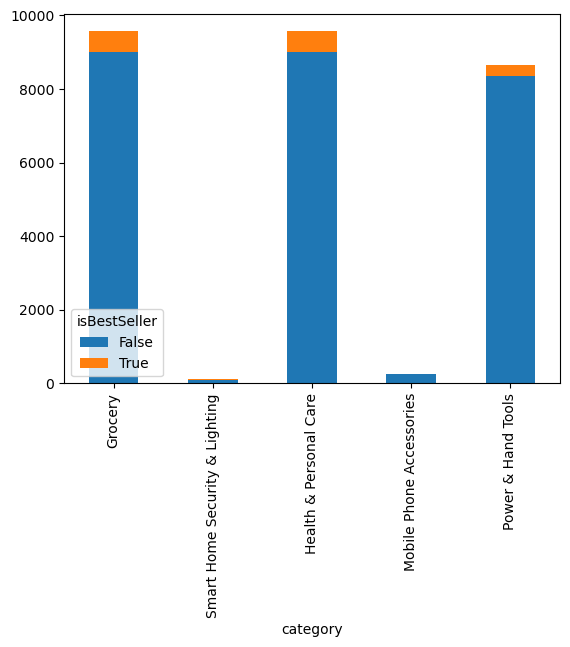

In [58]:
top_5_categories = best_seller_proportion.head(5).index
crosstab_top_5 = crosstab.loc[top_5_categories]
crosstab_top_5.plot(kind='bar', stacked=True)
plt.show()

Part 2: Exploring Product Prices and Ratings Across Categories and Brands
Objective: Investigate how different product categories influence product prices.

Preliminary Step: Remove outliers in product prices.

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

Violin Plots:

Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
Which product category tends to have the highest median price? Don't filter here by top categories.
Bar Charts:

Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
Which product category commands the highest average price? Don't filter here by top categories.
Box Plots:

Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [67]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# Verify by checking the shape of the cleaned dataframe
print(f"Original dataframe shape: {df.shape}")
print(f"Cleaned dataframe shape: {df_clean.shape}")

Original dataframe shape: (2443651, 9)
Cleaned dataframe shape: (2115963, 9)


/var/folders/yn/zzdysdkj6_z0rns53nqvdbvr0000gn/T/ipykernel_26602/2121781893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='category', y='price', data=df_top, palette="Set3")


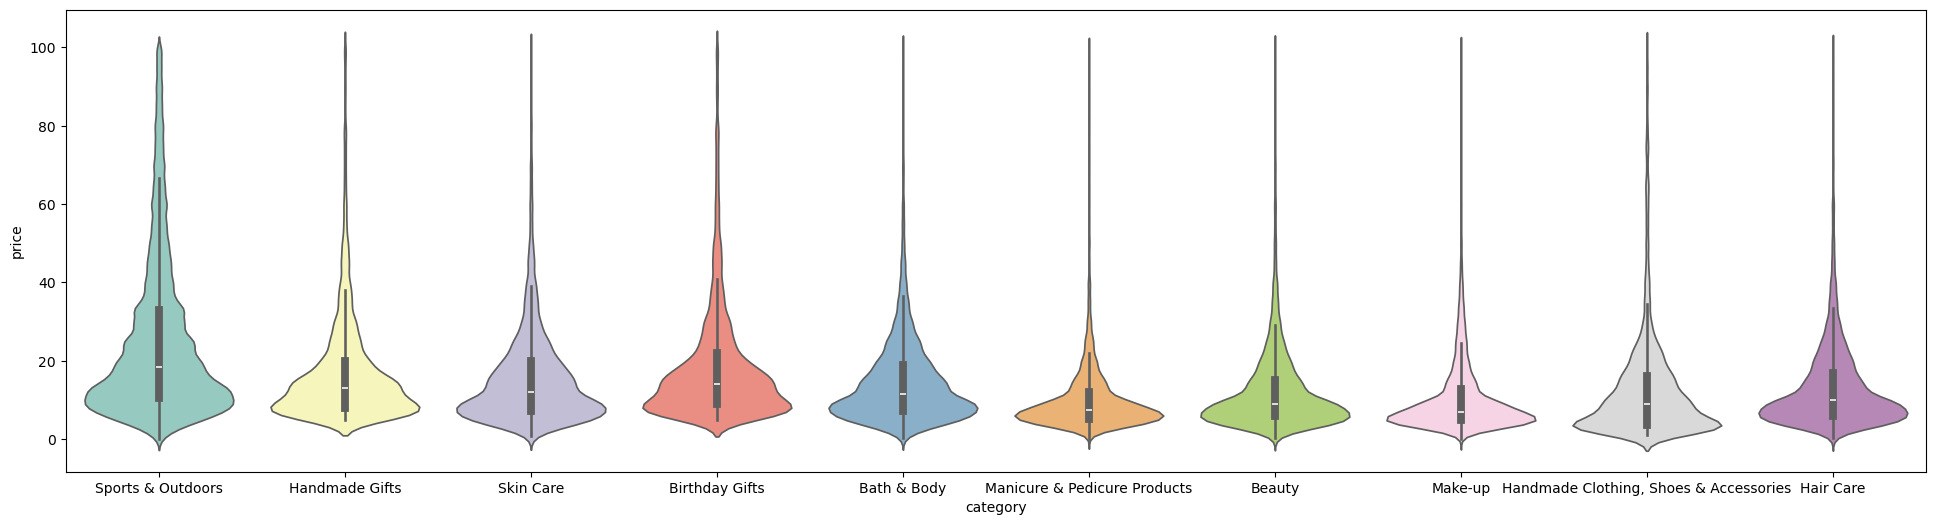

In [82]:
top_categories = df_clean['category'].value_counts().head(10).index
df_top = df_clean[df_clean['category'].isin(top_categories)]
plt.figure(figsize=(24, 6))
sns.violinplot(x='category', y='price', data=df_top, palette="Set3")
plt.show()

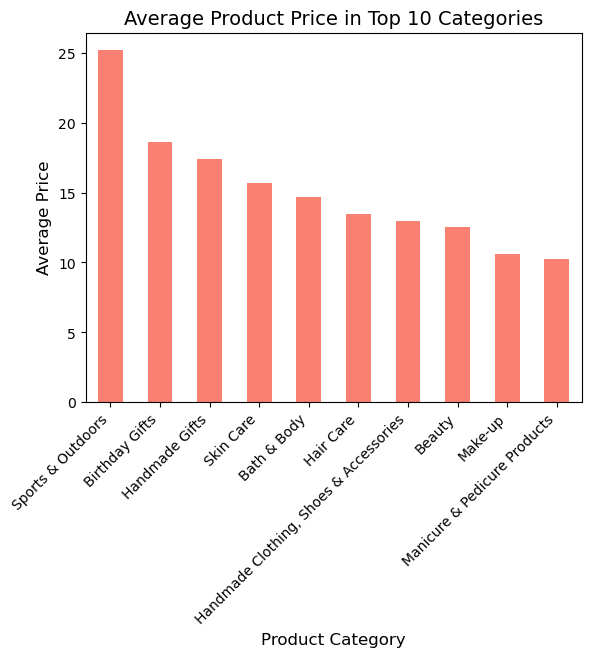

In [86]:
avg_price_by_category = df_clean[df_clean['category'].isin(top_categories)]\
    .groupby('category')['price'].mean().sort_values(ascending=False)

# Plot bar chart
# plt.figure(figsize=(10, 6))
avg_price_by_category.plot(kind='bar', color='salmon')
plt.title("Average Product Price in Top 10 Categories", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.show()


/var/folders/yn/zzdysdkj6_z0rns53nqvdbvr0000gn/T/ipykernel_26602/344579046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='stars', data=filtered_df[filtered_df['category'].isin(top_categories)], palette="Set2")


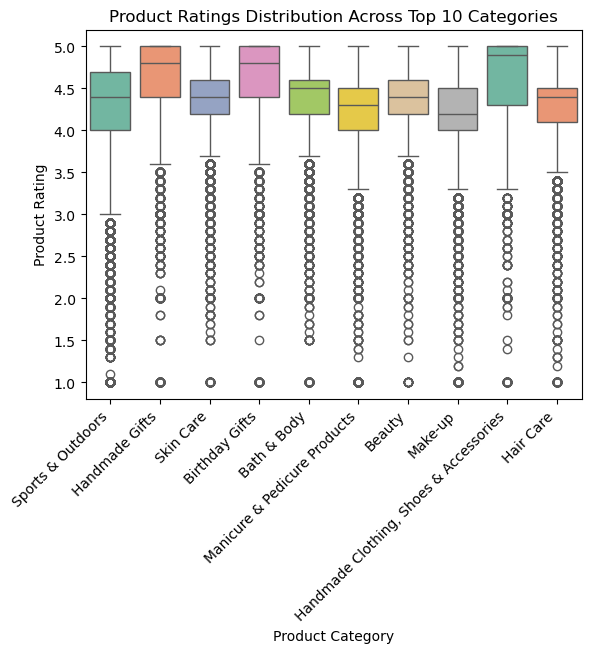

In [96]:
filtered_df = df_clean[df_clean['reviews']>0]
sns.boxplot(x='category', y='stars', data=filtered_df[filtered_df['category'].isin(top_categories)], palette="Set2")
plt.title("Product Ratings Distribution Across Top 10 Categories", fontsize=12)
plt.xlabel("Product Category", fontsize=10)
plt.ylabel("Product Rating", fontsize=10)
plt.xticks(rotation=45, ha="right")
plt.show()

Part 3: Investigating the Interplay Between Product Prices and Ratings
Objective: Analyze how product ratings (stars) correlate with product prices.

Correlation Coefficients:

Calculate the correlation coefficient between price and stars.
Is there a significant correlation between product price and its rating?
Visualizations:

Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
Use a correlation heatmap to visualize correlations between all numerical variables.
Examine if product prices typically follow a normal distribution using a QQ plot.

In [107]:
correlation_price_rating = filtered_df['price'].corr(filtered_df['stars'])
print(f"Correlation between Price and Rating: {correlation_price_rating:.2f}")

Correlation between Price and Rating: 0.01


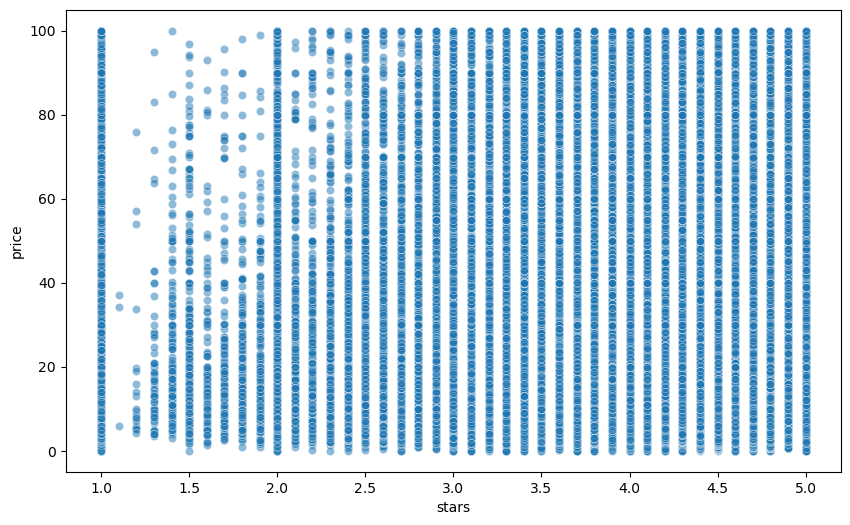

In [109]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=filtered_df['stars'], y=filtered_df['price'], alpha=0.5)
plt.show()

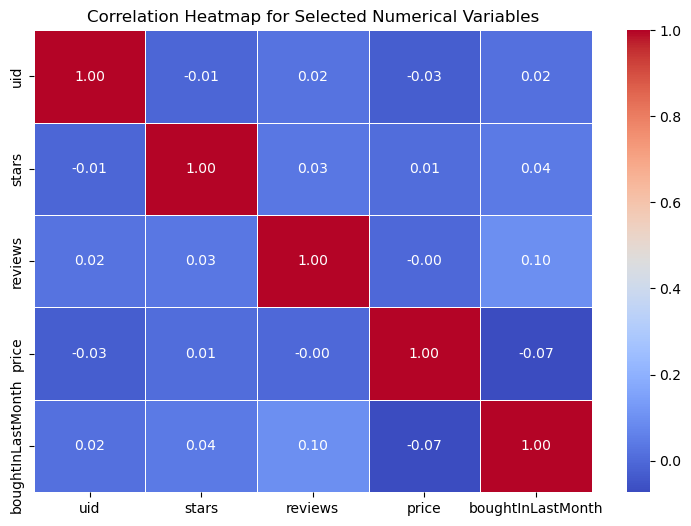

In [124]:
numerical_df = filtered_df.select_dtypes(include=['number'])

correlation_matrix = numerical_df.corr()
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

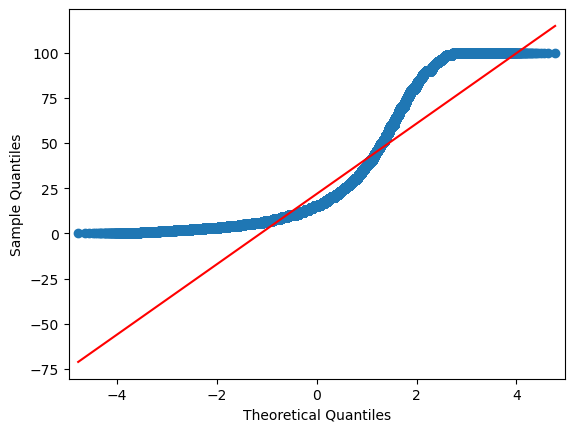

In [133]:
import statsmodels.api as sm

sm.qqplot(filtered_df['price'], line='s');